In [1]:
!pip install langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.5 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")


In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="llama-3.3-70b-versatile",
    temperature=0.7,
)

# LLM answer this ----->

In [10]:
llm.invoke("I want to know the meaning of water ").content

'The term "water" can have different meanings depending on the context. Here are a few possible interpretations:\n\n1. **Physical substance**: Water is a clear, colorless, odorless, and tasteless liquid substance that is essential for human life. It is a chemical compound made up of two hydrogen atoms and one oxygen atom (H2O). Water is vital for various biological processes, such as drinking, cleaning, and irrigation.\n2. **Symbolism and metaphor**: Water can also have symbolic or metaphorical meanings. For example:\n\t* **Emotions and feelings**: Water is often associated with emotions, such as calmness, serenity, or turmoil. It can represent the subconscious mind, intuition, or emotional depth.\n\t* **Spirituality and renewal**: Water is often used in spiritual contexts to represent purification, renewal, or spiritual growth. It can symbolize baptism, cleansing, or transformation.\n\t* **Change and adaptability**: Water can also represent change, adaptability, and fluidity. It can s

# But not able to answer this type question------>

In [11]:
llm.invoke("what is the temperature in LA").content

'I\'m not able to provide real-time information or current weather conditions. However, I can suggest some ways for you to find out the current temperature in Los Angeles (LA).\n\nYou can check the temperature in LA by:\n\n1. Checking online weather websites such as AccuWeather, Weather.com, or the National Weather Service (NWS) website.\n2. Using a mobile app like Dark Sky or Weather Underground.\n3. Watching local news or checking the website of a local news station in LA.\n4. Searching for "current temperature in Los Angeles" on a search engine like Google.\n\nPlease note that temperatures in LA can vary depending on the time of year, location, and other factors, so it\'s always a good idea to check the current conditions before planning your day.'

# First Graph

### Step 1:Define the Schema

In [6]:
from typing import TypedDict,List

In [7]:
class graph_schema(TypedDict):
  name:str
  message:str

### Step2:create the node Function

In [13]:
def welcome(state:graph_schema)->graph_schema:
  curr_name=state['name']
  curr_message=state['message']
  response=llm.invoke(f"My name is {curr_name}.{curr_message}").content
  # change the current state message (user message) to AI message
  state['message']=f"your message was {curr_message}.Here is my response: {response}"
  return state

### Step3:create The State Graph

In [16]:
from langgraph.graph import StateGraph,START,END
graph= StateGraph(graph_schema)
#Adding node
graph.add_node("Welcome",welcome)

#add edge of the node start and end point
graph.add_edge(START,"Welcome")
graph.add_edge("Welcome",END)

### Step 4: Complie the graph

In [17]:
first_graph=graph.compile()

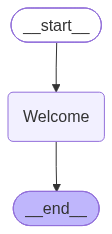

In [28]:
from IPython.display import Image,display
#You could se errors with the below cmnd
Image(first_graph.get_graph().draw_mermaid_png())


In [29]:
#then you can use the below cmnd to see the graph code not the graph without errors
print(first_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	Welcome(Welcome)
	__end__([<p>__end__</p>]):::last
	__start__ --> Welcome;
	Welcome --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
#to see the exact graph with the given graph code which is above output ,paste the code in mermid website

### Step5- Run the Graph

In [30]:
first_graph.invoke({"name":"Biswajit","message":" How are you ?"})

{'name': 'Biswajit',
 'message': "your message was  How are you ?.Here is my response: Hello Biswajit! I'm just a language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help you with any questions or topics you'd like to discuss. It's nice to meet you! How can I assist you today?"}

### So this is AI response so through langraph now you are not seeing any random messages and responses like langchain.Now you are seeing response in the exact schema that you created in langraph .Langchain was not obeying the schema that you wanted.Because you are building the downstream dependencies.when you  make it ,your responses that you generting is actullay following the exact schema or basically exact state . It follow this ecact  state becuse of langgraph and we are manually updating the state (function welcome).LLM not interfare in that to make this .I am generating the response for sure but I am manually filling data in state .That is the power of Stateful orchestration.